# nuScenes Agent-Centric Trajectory Analysis

This notebook computes and visualizes 8 trajectory analysis metrics for the nuScenes mini dataset using trajdata.

## Setup and Data Loading

In [1]:
# Import required libraries
import os
import sys
import json
import pickle
import warnings
from collections import Counter, defaultdict
from pathlib import Path

# Ensure Matplotlib can write its cache/config inside the repo
os.environ.setdefault('MPLCONFIGDIR', str((Path('..') / '.mplconfig').resolve()))

import matplotlib
# Work around matplotlib_inline expecting a private rcParams._get attribute
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get  # type: ignore[attr-defined]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Make local src/ importable when running from notebooks/
SRC_ROOT = Path('..') / 'src'
if str(SRC_ROOT.resolve()) not in sys.path:
    sys.path.append(str(SRC_ROOT.resolve()))

# Import trajdata + characteristic metric functions
from trajdata import AgentType, UnifiedDataset
from trajdata.data_structures.data_index import AgentDataIndex
from shared_config.attention_config import load_attention_radius
from data_preparation.functions_traj_metrics.agent_centric_characteristic_metrics import (
    CharacteristicMetricConfig,
    compute_characteristic_metrics,
)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Libraries loaded successfully')


/Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded successfully


In [2]:
# Load configuration (analysis defaults + optional run config override)
CONFIG_PATH = Path('../config/analysis_config.yaml')
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

dataset_mode = str(config['dataset'].get('mode', 'exploratory')).strip().lower()
run_cfg_section = config.get('run_config', {})
use_run_config = dataset_mode == 'eval_aligned' and bool(run_cfg_section.get('enabled', False))

run_config = None
run_config_path = None
if use_run_config:
    explicit_path = str(run_cfg_section.get('config_path', '')).strip()
    run_name = str(run_cfg_section.get('run_name', '')).strip()
    if explicit_path:
        run_config_path = Path(explicit_path)
    elif run_name:
        run_config_path = Path('../results/trajectory_prediction/nuScenes/models') / run_name / 'config.json'

    if run_config_path is None or not run_config_path.exists():
        print('⚠ dataset.mode=eval_aligned but no valid run config was found; falling back to exploratory mode')
        use_run_config = False
        dataset_mode = 'exploratory'
    else:
        with open(run_config_path, 'r', encoding='utf-8') as f:
            run_config = json.load(f)
        print(f'✓ Run configuration loaded from {run_config_path}')

print(f'✓ Base configuration loaded from {CONFIG_PATH}')
print(f'  Dataset mode: {dataset_mode}')


✓ Configuration loaded from ../config/analysis_config.yaml


In [3]:
# Configure data paths and derive the effective dataset settings
NUSCENES_ROOT = Path(config['dataset']['root_path']).resolve()
CACHE_DIR = Path(config['dataset']['cache_path']).resolve()
RESULTS_DIR = Path(config['output']['results_dir']).resolve()
PLOTS_DIR = Path(config['output']['plots_dir']).resolve()
METRICS_DIR = Path(config['output']['metrics_dir']).resolve()

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

if not NUSCENES_ROOT.exists():
    raise FileNotFoundError(f'nuScenes root not found at {NUSCENES_ROOT}')

# Load shared attention radii (aligned with train_unified.py defaults)
attention_radius = load_attention_radius()

# Agent-centric analysis defaults
agent_cfg = config['trajdata']['agent_centric']
analysis_history_sec = tuple(agent_cfg['history_sec'])
analysis_future_sec = tuple(agent_cfg['future_sec'])

# Helper: parse data_loc_dict from a run config, but fall back to local paths when needed
def _effective_data_dirs(default_name: str) -> dict:
    base_dirs = {default_name: str(NUSCENES_ROOT)}
    if run_config is None:
        return base_dirs
    try:
        run_dirs = json.loads(run_config.get('data_loc_dict', '{}'))
    except Exception:
        return base_dirs
    resolved = {}
    for key, path in run_dirs.items():
        p = Path(path).expanduser()
        resolved[key] = str(p if p.exists() else NUSCENES_ROOT)
    return resolved or base_dirs


def restrict_to_predchal(dataset: UnifiedDataset, split: str, city: str = '') -> None:
    """Mirror train_unified.py's nuScenes prediction challenge filtering."""
    predchal_path = Path('..') / 'config' / 'experimental_setup' / 'nuScenes' / f'predchal{city}_{split}_index.pkl'
    if not predchal_path.exists():
        raise FileNotFoundError(f'Prediction challenge index not found at {predchal_path}')
    with open(predchal_path, 'rb') as f:
        within_challenge_split = pickle.load(f)
    within_challenge_split = [
        (dataset.cache_path / scene_info_path, num_elems, elems)
        for scene_info_path, num_elems, elems in within_challenge_split
    ]
    dataset._scene_index = [orig_path for orig_path, _, _ in within_challenge_split]
    dataset._data_index = AgentDataIndex(within_challenge_split, dataset.verbose)
    dataset._data_len = len(dataset._data_index)

# Derive effective dataset settings
if dataset_mode == 'eval_aligned' and run_config is not None:
    eval_data_name = run_config.get('eval_data', config['dataset']['name'])
    eval_history_sec = float(run_config.get('history_sec', analysis_history_sec[1]))
    eval_prediction_sec = float(run_config.get('prediction_sec', analysis_future_sec[1]))
    incl_raster_map = bool(run_config.get('map_encoding', config['trajdata']['incl_raster_map']))
    incl_robot_future = bool(run_config.get('incl_robot_node', False))
    cache_location = Path(run_config.get('trajdata_cache_dir', str(CACHE_DIR))).expanduser()
    num_workers = int(run_config.get('preprocess_workers', config['trajdata']['num_workers']))
    data_dirs = _effective_data_dirs(config['dataset']['name'])
else:
    eval_data_name = config['dataset']['name']
    eval_history_sec = float(analysis_history_sec[1])
    eval_prediction_sec = float(analysis_future_sec[1])
    incl_raster_map = bool(config['trajdata']['incl_raster_map'])
    incl_robot_future = False
    cache_location = CACHE_DIR.expanduser()
    num_workers = int(config['trajdata']['num_workers'])
    data_dirs = {config['dataset']['name']: str(NUSCENES_ROOT)}

if not cache_location.exists():
    cache_location = CACHE_DIR.expanduser()

print(f'Data directory: {NUSCENES_ROOT}')
print(f'Cache directory: {cache_location}')
print(f'Plots directory: {PLOTS_DIR}')
print(f'Metrics directory: {METRICS_DIR}')
print(f'Desired data: {eval_data_name}')
print(f'History/Future (s): {eval_history_sec} / {eval_prediction_sec}')


Data directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/data/raw
Cache directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/data/processed/trajdata_cache
Plots directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/evaluation/plots/characterization
Metrics directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/evaluation/metrics


In [4]:
# Define map parameters
map_params_analysis = {
    'px_per_m': config['trajdata']['map_params']['px_per_m'],
    'map_size_px': config['trajdata']['map_params']['map_size_px'],
}
map_params_eval = {'px_per_m': 2, 'map_size_px': 100, 'offset_frac_xy': (-0.75, 0.0)}

if dataset_mode == 'eval_aligned' and run_config is not None:
    # Mirror train_unified.py's eval dataset definition as closely as possible
    dataset = UnifiedDataset(
        desired_data=[eval_data_name],
        centric='agent',
        history_sec=(eval_history_sec, eval_history_sec),
        future_sec=(eval_prediction_sec, eval_prediction_sec),
        agent_interaction_distances=attention_radius,
        incl_robot_future=incl_robot_future,
        incl_raster_map=incl_raster_map,
        raster_map_params=map_params_eval,
        incl_vector_map=config['trajdata']['incl_vector_map'],
        only_predict=[AgentType.VEHICLE, AgentType.PEDESTRIAN],
        no_types=[AgentType.UNKNOWN],
        verbose=True,
        data_dirs=data_dirs,
        cache_location=str(cache_location),
        num_workers=num_workers,
    )

    if eval_data_name == 'nusc_trainval-train_val':
        restrict_to_predchal(dataset, 'train_val')
else:
    # Exploratory: use analysis_config.yaml settings directly
    dataset = UnifiedDataset(
        desired_data=[eval_data_name],
        centric='agent',
        desired_dt=agent_cfg.get('desired_dt', None),
        history_sec=analysis_history_sec,
        future_sec=analysis_future_sec,
        agent_interaction_distances=attention_radius,
        incl_raster_map=incl_raster_map,
        raster_map_params=map_params_analysis,
        incl_vector_map=config['trajdata']['incl_vector_map'],
        incl_robot_future=incl_robot_future,
        only_predict=[AgentType.VEHICLE, AgentType.PEDESTRIAN],
        no_types=[AgentType.UNKNOWN],
        max_neighbor_num=None,
        verbose=True,
        data_dirs=data_dirs,
        cache_location=str(cache_location),
        num_workers=num_workers,
    )

print('')
print(f"✓ Dataset loaded: {len(dataset)} agent trajectories")


Loading data for matched scene tags: ['boston-mini_train-nusc_mini', 'mini_train-singapore-nusc_mini', 'boston-mini_val-nusc_mini', 'singapore-mini_val-nusc_mini']


Calculating Agent Data (Serially): 100%|██████████| 10/10 [00:00<00:00, 14952.96it/s]


10 scenes in the scene index.


Structuring Agent Data Index: 100%|██████████| 10/10 [00:00<00:00, 10798.93it/s]


✓ Dataset loaded: 25197 agent trajectories


## Metric 1: Agent Type Distribution

Analyze the distribution of different agent types in the dataset.

### What is computed:

This metric analyzes the **distribution of agent types** in the dataset (e.g., vehicles, pedestrians, cyclists). It counts how many trajectories belong to each agent category.

### How it works:

1. **Random Sampling**: Selects up to 5,000 random trajectories from the dataset to make computation feasible
2. **Agent Type Extraction**: For each sampled trajectory, extracts the agent type from `batch.agent_type.name`
3. **Counting**: Uses `Counter` to tally occurrences of each agent type
4. **Percentage Calculation**: Computes the proportion of each agent type relative to total samples

### Output:
- Count and percentage for each agent type (e.g., VEHICLE, PEDESTRIAN)
- Bar chart visualization showing the distribution

In [5]:
print("Collecting agent type distribution...")

# Setup output path
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

agent_types = []
sample_size = min(config['analysis']['sample_size'], len(dataset))
indices = np.random.choice(len(dataset), sample_size, replace=False)

for idx in tqdm(indices, desc="Analyzing agent types"):
    batch = dataset[idx]
    agent_types.append(batch.agent_type.name)

agent_type_counts = Counter(agent_types)
print(f"\n✓ Agent type distribution computed from {len(agent_types)} samples")
print(f"\nAgent type breakdown:")
for agent_type, count in agent_type_counts.most_common():
    print(f"  {agent_type}: {count} ({count/len(agent_types)*100:.1f}%)")

Analyzing agent types: 100%|██████████| 5000/5000 [01:11<00:00, 70.11it/s]


✓ Agent type distribution computed from 5000 samples

Agent type breakdown:
  VEHICLE: 3035 (60.7%)
  PEDESTRIAN: 1731 (34.6%)
  MOTORCYCLE: 184 (3.7%)
  BICYCLE: 50 (1.0%)


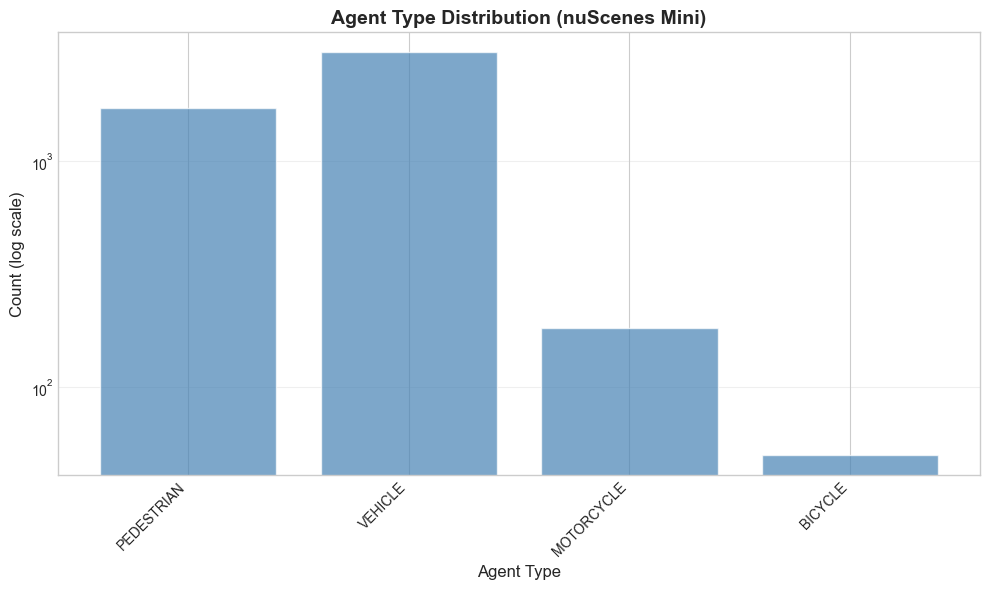

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
types = list(agent_type_counts.keys())
counts = list(agent_type_counts.values())

ax.bar(types, counts, color='steelblue', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Count (log scale)', fontsize=12)
ax.set_title('Agent Type Distribution (nuScenes Mini)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig(PLOTS_DIR / 'agent_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Metric 2: Velocity Distribution

Analyze velocity patterns across different agent types.

### What is computed:

This metric analyzes **velocity profiles** of agents, computing speed statistics from their movement trajectories.

### How it works:

1. **Trajectory Concatenation**: Combines history and future trajectories into one continuous path using `np.vstack()`
2. **Velocity Calculation**: Computes velocity vectors between consecutive positions using `np.diff()` divided by time step (0.1s)
3. **Speed Extraction**: Calculates instantaneous speeds as the magnitude of velocity vectors using `np.linalg.norm()`
4. **Statistical Aggregation**: For each trajectory, computes:
   - **Mean speed**: Average velocity over the entire trajectory
   - **Max speed**: Peak velocity reached
   - **Speed variance**: Standard deviation measuring speed variability

### Output:
- Speed distribution statistics (mean, max, std) for all sampled trajectories
- Histogram showing the distribution of mean speeds across agents

In [7]:
print('Computing agent-centric characteristic metrics (once per sampled trajectory)...')

metric_cfg = CharacteristicMetricConfig(
    collision_threshold_m=config['analysis']['collision_threshold_m'],
    lane_threshold_m=config['analysis']['off_road_threshold_m'],
)

metric_rows = []
for idx in tqdm(indices, desc='Characteristic metrics'):
    elem = dataset[int(idx)]
    metrics = compute_characteristic_metrics(elem, metric_cfg)
    scene_path, agent_id, scene_ts = dataset._data_index[int(idx)]
    metrics.update(
        {
            'data_idx': int(idx),
            'agent_id': agent_id,
            'scene_path': scene_path,
            'scene_ts': int(scene_ts),
            'agent_type': elem.agent_type.name,
        }
    )
    metric_rows.append(metrics)

metrics_df = pd.DataFrame(metric_rows)
print(f"✓ Characteristic metrics computed for {len(metrics_df)} trajectories")

# Velocity-specific view for downstream plots
velocity_df = metrics_df[['agent_type', 'mean_speed', 'max_speed', 'std_speed']].copy()
print('')
print('Overall statistics:')
print(f"  Mean speed: {velocity_df['mean_speed'].mean():.2f} m/s")
print(f"  Max speed observed: {velocity_df['max_speed'].max():.2f} m/s")


Computing velocity distributions...


Computing velocities: 100%|██████████| 5000/5000 [01:15<00:00, 66.01it/s]


✓ Velocity data computed for 5000 trajectories

Overall statistics:
  Mean speed: 1.91 m/s
  Max speed observed: 50.61 m/s


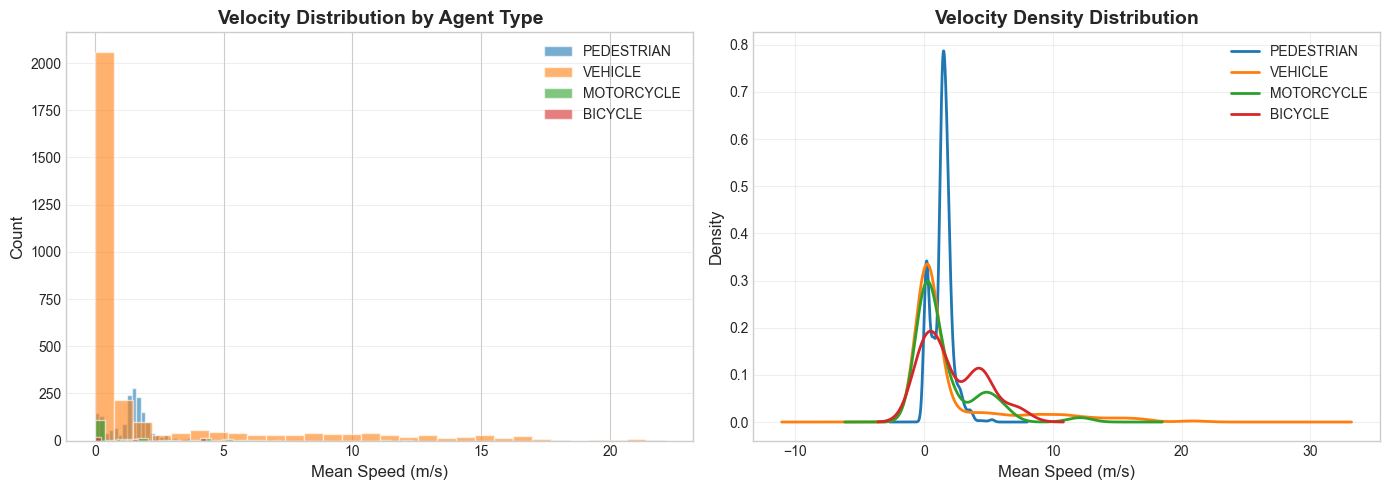

In [8]:
# Visualize velocity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked histogram by agent type
ax = axes[0]
for agent_type in velocity_df['agent_type'].unique():
    subset = velocity_df[velocity_df['agent_type'] == agent_type]['mean_speed']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Mean Speed (m/s)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Velocity Distribution by Agent Type', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# KDE plot
ax = axes[1]
for agent_type in velocity_df['agent_type'].unique():
    subset = velocity_df[velocity_df['agent_type'] == agent_type]['mean_speed']
    subset.plot.kde(ax=ax, label=agent_type, linewidth=2)
ax.set_xlabel('Mean Speed (m/s)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Velocity Density Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'velocity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Metric 3: Acceleration Distribution

Analyze acceleration patterns with jerk overlay.

### What is computed:

This metric analyzes **acceleration and jerk** (rate of change of acceleration) to understand agent motion dynamics and smoothness.

### How it works:

1. **Velocity Calculation**: Computes velocity from position differences (same as Metric 2)
2. **Speed Series**: Extracts scalar speeds from velocity vectors
3. **Acceleration Computation**:
   - Takes the difference between consecutive speeds: `np.diff(speeds)`
   - Divides by time step (0.1s) to get acceleration in m/s^2
4. **Jerk Computation**:
   - Takes the difference of accelerations: `np.diff(accelerations)`
   - Divides by time step to get jerk in m/s^3
5. **Statistical Aggregation**: Records mean and maximum values for both acceleration and jerk

### Output:
- Mean and maximum acceleration magnitudes
- Mean and maximum jerk values
- Histogram visualizations for both metrics

In [9]:
print('Preparing acceleration and jerk metrics from cached characteristic metrics...')

accel_df = metrics_df[
    ['agent_type', 'mean_acceleration', 'max_acceleration', 'mean_jerk', 'max_jerk']
].copy()

print('')
print(f"✓ Acceleration data prepared for {len(accel_df)} trajectories")
print('')
print('Overall statistics:')
print(f"  Mean acceleration magnitude: {accel_df['mean_acceleration'].abs().mean():.2f} m/s²")
print(f"  Mean jerk: {accel_df['mean_jerk'].mean():.2f} m/s³")


Computing acceleration and jerk distributions...


Computing accelerations: 100%|██████████| 5000/5000 [01:16<00:00, 65.00it/s]


✓ Acceleration data computed for 5000 trajectories

Overall statistics:
  Mean acceleration magnitude: 0.13 m/s²
  Mean jerk: 17.54 m/s³


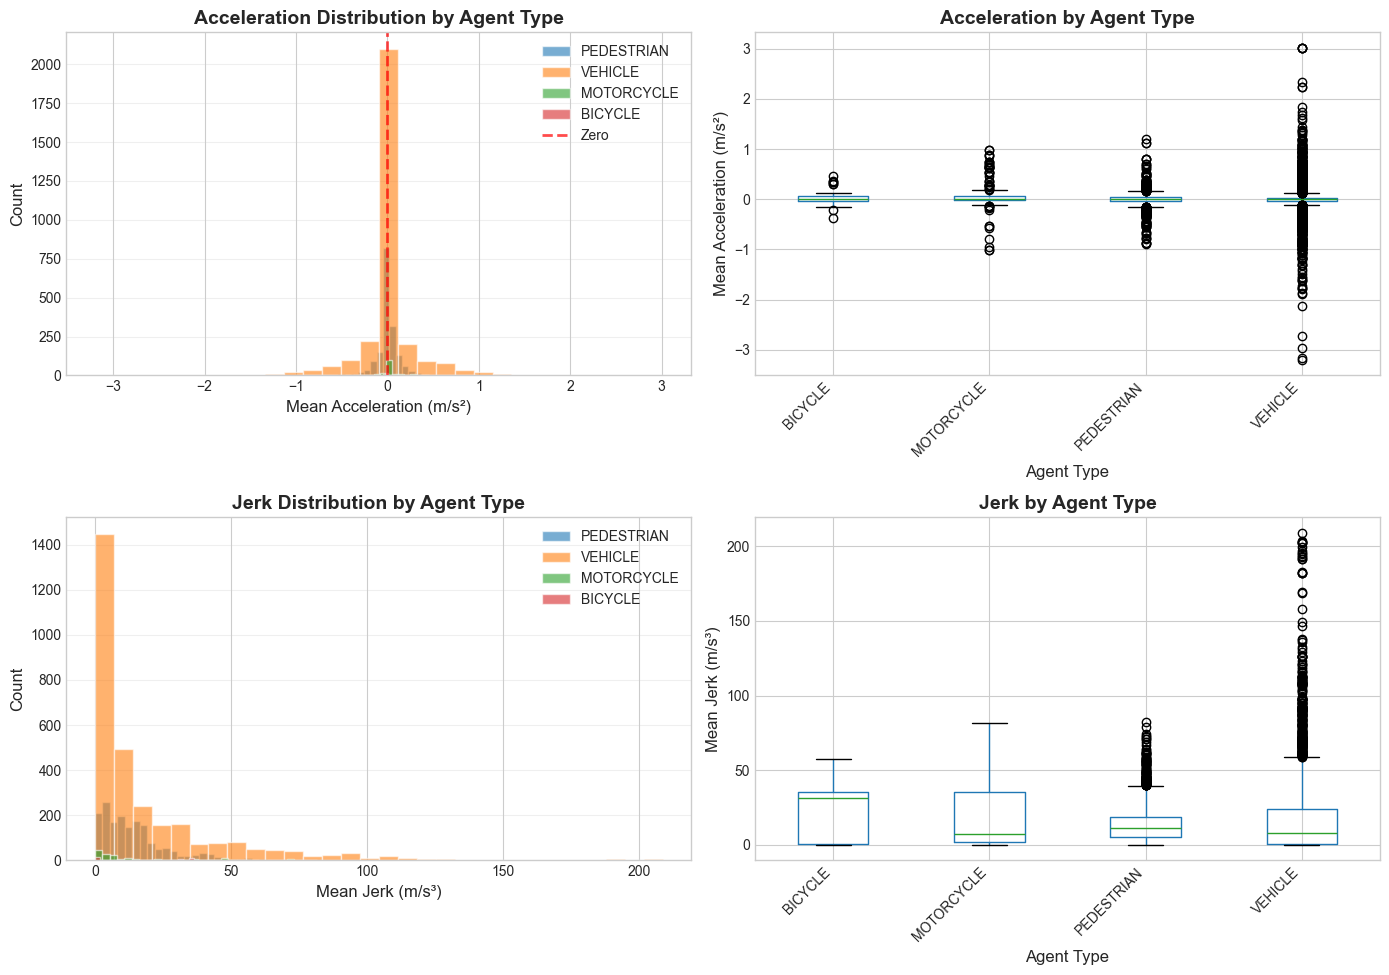


Acceleration & Jerk Statistics by Agent Type:

PEDESTRIAN:
  Mean acceleration: 0.08 m/s²
  Max acceleration: 67.69 m/s²
  Mean jerk: 14.67 m/s³
  Max jerk: 676.91 m/s³
  Count: 1731

VEHICLE:
  Mean acceleration: 0.16 m/s²
  Max acceleration: 296.02 m/s²
  Mean jerk: 19.01 m/s³
  Max jerk: 2960.20 m/s³
  Count: 3035

MOTORCYCLE:
  Mean acceleration: 0.16 m/s²
  Max acceleration: 85.55 m/s²
  Mean jerk: 19.06 m/s³
  Max jerk: 855.54 m/s³
  Count: 184

BICYCLE:
  Mean acceleration: 0.09 m/s²
  Max acceleration: 61.14 m/s²
  Mean jerk: 22.03 m/s³
  Max jerk: 611.40 m/s³
  Count: 50


In [10]:
# Visualize acceleration distribution with jerk overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Acceleration histogram by agent type
ax = axes[0, 0]
for agent_type in accel_df['agent_type'].unique():
    subset = accel_df[accel_df['agent_type'] == agent_type]['mean_acceleration']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Mean Acceleration (m/s²)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Acceleration Distribution by Agent Type', fontsize=14, fontweight='bold')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Zero')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Acceleration boxplot by agent type
ax = axes[0, 1]
accel_df.boxplot(column='mean_acceleration', by='agent_type', ax=ax)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Mean Acceleration (m/s²)', fontsize=12)
ax.set_title('Acceleration by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.get_figure().suptitle('')  # Remove default title

# Jerk histogram by agent type
ax = axes[1, 0]
for agent_type in accel_df['agent_type'].unique():
    subset = accel_df[accel_df['agent_type'] == agent_type]['mean_jerk']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Mean Jerk (m/s³)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Jerk Distribution by Agent Type', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Jerk boxplot by agent type
ax = axes[1, 1]
accel_df.boxplot(column='mean_jerk', by='agent_type', ax=ax)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Mean Jerk (m/s³)', fontsize=12)
ax.set_title('Jerk by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'acceleration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\nAcceleration & Jerk Statistics by Agent Type:")
for agent_type in accel_df['agent_type'].unique():
    subset = accel_df[accel_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Mean acceleration: {subset['mean_acceleration'].abs().mean():.2f} m/s²")
    print(f"  Max acceleration: {subset['max_acceleration'].max():.2f} m/s²")
    print(f"  Mean jerk: {subset['mean_jerk'].mean():.2f} m/s³")
    print(f"  Max jerk: {subset['max_jerk'].max():.2f} m/s³")
    print(f"  Count: {len(subset)}")

## Metric 4: Observation Duration

Analyze the duration of observed trajectories.

### What is computed:

This metric measures **how long each agent is observed** in the dataset, broken down into historical and future components.

### How it works:

1. **History Duration**:
   - Counts timesteps in `agent_history_np` (past observations)
   - Multiplies by time step (0.1s) to convert to seconds
2. **Future Duration**:
   - Counts timesteps in `agent_future_np` (future predictions/observations)
   - Multiplies by time step (0.1s)
3. **Total Duration**: Sums history and future durations

### Output:
- Distribution of total observation times
- Breakdown showing mean history vs. future duration
- Histogram of observation durations

In [11]:
print('Preparing observation duration metrics from cached characteristic metrics...')

duration_df = metrics_df[
    ['agent_type', 'duration', 'history_duration', 'future_duration']
].copy()

print('')
print(f"✓ Duration data prepared for {len(duration_df)} trajectories")
print('')
print('Overall statistics:')
print(f"  Mean total duration: {duration_df['duration'].mean():.2f} s")
print(f"  Mean history duration: {duration_df['history_duration'].mean():.2f} s")
print(f"  Mean future duration: {duration_df['future_duration'].mean():.2f} s")


Computing observation durations...


Computing durations: 100%|██████████| 5000/5000 [01:16<00:00, 65.78it/s]


✓ Duration data computed for 5000 trajectories

Overall statistics:
  Mean total duration: 8.10 s
  Mean history duration: 3.30 s
  Mean future duration: 4.80 s


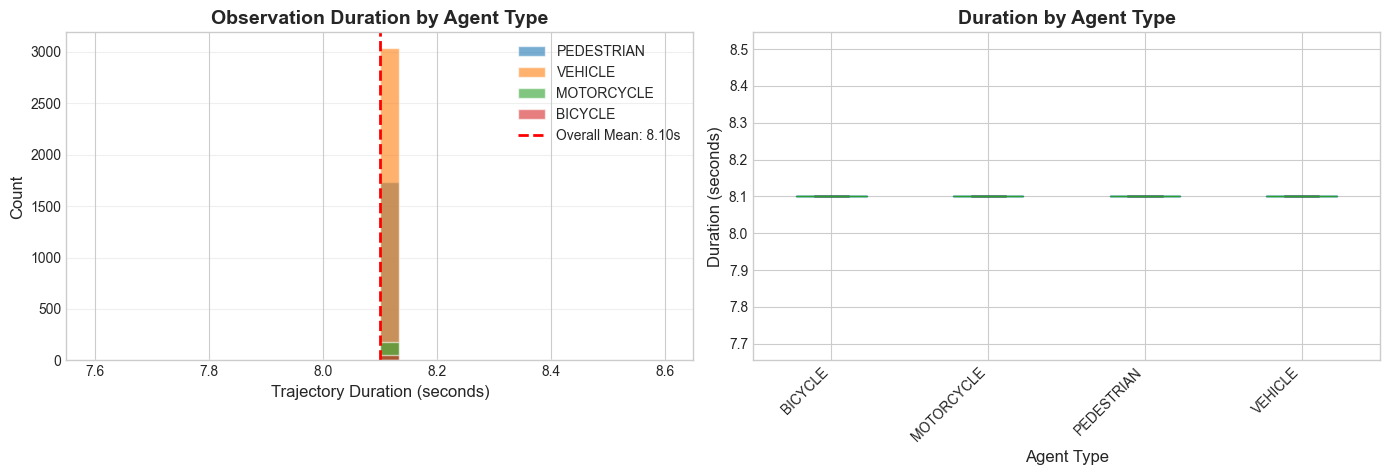


Duration Statistics by Agent Type:

PEDESTRIAN:
  Mean total duration: 8.10 s
  Mean history duration: 3.30 s
  Mean future duration: 4.80 s
  Count: 1731

VEHICLE:
  Mean total duration: 8.10 s
  Mean history duration: 3.30 s
  Mean future duration: 4.80 s
  Count: 3035

MOTORCYCLE:
  Mean total duration: 8.10 s
  Mean history duration: 3.30 s
  Mean future duration: 4.80 s
  Count: 184

BICYCLE:
  Mean total duration: 8.10 s
  Mean history duration: 3.30 s
  Mean future duration: 4.80 s
  Count: 50


In [12]:
# Visualize observation duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by agent type
ax = axes[0]
for agent_type in duration_df['agent_type'].unique():
    subset = duration_df[duration_df['agent_type'] == agent_type]['duration']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Trajectory Duration (seconds)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Observation Duration by Agent Type', fontsize=14, fontweight='bold')
ax.axvline(duration_df['duration'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Overall Mean: {duration_df["duration"].mean():.2f}s')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Boxplot by agent type
ax = axes[1]
duration_df.boxplot(column='duration', by='agent_type', ax=ax)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Duration (seconds)', fontsize=12)
ax.set_title('Duration by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'observation_duration.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\nDuration Statistics by Agent Type:")
for agent_type in duration_df['agent_type'].unique():
    subset = duration_df[duration_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Mean total duration: {subset['duration'].mean():.2f} s")
    print(f"  Mean history duration: {subset['history_duration'].mean():.2f} s")
    print(f"  Mean future duration: {subset['future_duration'].mean():.2f} s")
    print(f"  Count: {len(subset)}")

## Metric 5: Ego-Agent Distance

Analyze distance between ego vehicle and agents using robot_future_np.

### What is computed:

This metric measures the **spatial distance between each agent and the ego vehicle** (the autonomous vehicle from whose perspective the scene is observed).

### How it works:

1. **Agent Position**: Extracts the agent's current position from the last timestep of history: `agent_history_np[-1, :2]`
2. **Ego Position**: Extracts ego vehicle position from the first timestep of robot future: `robot_future_np[0, :2]`
3. **Distance Calculation**: Computes Euclidean distance using `np.linalg.norm(agent_pos - ego_pos)`
4. **Filtering**: Only includes trajectories where ego position data is available

### Output:
- Mean, median, and minimum ego-agent distances
- Histogram showing distance distribution
- Insights into sensor coverage and agent proximity to ego vehicle

In [13]:
print("Computing ego-agent distances...")

ego_distance_data = []

for idx in tqdm(indices, desc="Computing ego distances"):
    batch = dataset[idx]

    # Agent position at current timestep (end of history)
    agent_pos = batch.agent_history_np[-1, :2]

    robot_future = getattr(batch, "robot_future_np", None)
    if robot_future is None or len(robot_future) == 0:
        continue

    # Ego position at current timestep (start of robot_future)
    ego_pos = robot_future[0, :2]
    distance = np.linalg.norm(agent_pos - ego_pos)

    ego_distance_data.append({
        "agent_type": batch.agent_type.name,
        "ego_distance": distance,
    })

ego_distance_df = pd.DataFrame(ego_distance_data, columns=["agent_type", "ego_distance"])
count = len(ego_distance_df)
print(f"\n✓ Ego-agent distance computed for {count} trajectories")

if count == 0:
    print("\nNo robot/ego trajectory is available in this dataset configuration.")
    print("Ego-agent distance plots will be skipped.")
else:
    print("\nOverall statistics:")
    print(f"  Mean ego distance: {ego_distance_df['ego_distance'].mean():.2f} m")
    print(f"  Median ego distance: {ego_distance_df['ego_distance'].median():.2f} m")
    print(f"  Min ego distance: {ego_distance_df['ego_distance'].min():.2f} m")


Computing ego-agent distances...


Computing ego distances: 100%|██████████| 5000/5000 [01:17<00:00, 64.25it/s]


✓ Ego-agent distance computed for 5000 trajectories

Overall statistics:
  Mean ego distance: 28.47 m
  Median ego distance: 24.32 m
  Min ego distance: 3.04 m


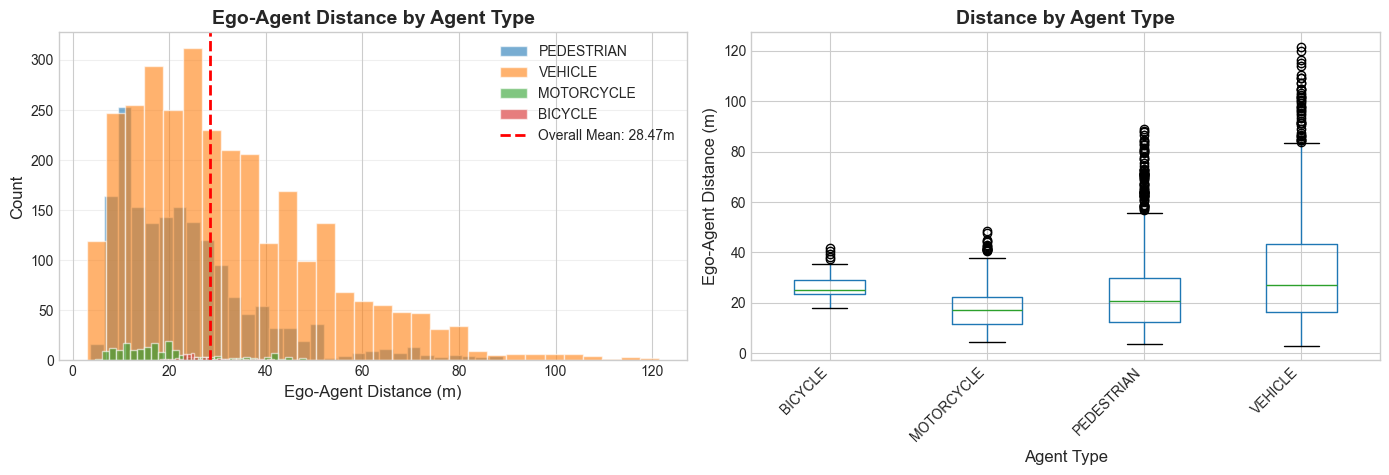


Ego-Agent Distance Statistics by Agent Type:

PEDESTRIAN:
  Mean distance: 23.77 m
  Median distance: 20.71 m
  Min distance: 3.64 m
  Max distance: 89.10 m
  Count: 1731

VEHICLE:
  Mean distance: 31.73 m
  Median distance: 27.14 m
  Min distance: 3.04 m
  Max distance: 121.40 m
  Count: 3035

MOTORCYCLE:
  Mean distance: 19.30 m
  Median distance: 16.99 m
  Min distance: 4.60 m
  Max distance: 48.32 m
  Count: 184

BICYCLE:
  Mean distance: 27.08 m
  Median distance: 24.98 m
  Min distance: 18.13 m
  Max distance: 41.75 m
  Count: 50


In [14]:
if ego_distance_df.empty:
    print("Skipping ego-agent distance plots; no ego trajectory available.")
else:
    # Visualize ego-agent distance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram by agent type
    ax = axes[0]
    for agent_type in ego_distance_df["agent_type"].unique():
        subset = ego_distance_df[ego_distance_df["agent_type"] == agent_type]["ego_distance"]
        ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
    ax.set_xlabel("Ego-Agent Distance (m)", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title("Ego-Agent Distance by Agent Type", fontsize=14, fontweight="bold")
    ax.axvline(
        ego_distance_df["ego_distance"].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Overall Mean: {ego_distance_df['ego_distance'].mean():.2f}m",
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Boxplot by agent type
    ax = axes[1]
    ego_distance_df.boxplot(column="ego_distance", by="agent_type", ax=ax)
    ax.set_xlabel("Agent Type", fontsize=12)
    ax.set_ylabel("Ego-Agent Distance (m)", fontsize=12)
    ax.set_title("Distance by Agent Type", fontsize=14, fontweight="bold")
    plt.sca(ax)
    plt.xticks(rotation=45, ha="right")
    ax.get_figure().suptitle("")  # Remove default title

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "ego_agent_distance.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Print statistics by agent type
    print("\nEgo-Agent Distance Statistics by Agent Type:")
    for agent_type in ego_distance_df["agent_type"].unique():
        subset = ego_distance_df[ego_distance_df["agent_type"] == agent_type]
        print(f"\n{agent_type}:")
        print(f"  Mean distance: {subset['ego_distance'].mean():.2f} m")
        print(f"  Median distance: {subset['ego_distance'].median():.2f} m")
        print(f"  Min distance: {subset['ego_distance'].min():.2f} m")
        print(f"  Max distance: {subset['ego_distance'].max():.2f} m")
        print(f"  Count: {len(subset)}")


## Metric 6: Path Efficiency

Compute displacement/path-length ratio to identify trajectory linearity.

### What is computed:

This metric measures **how direct an agent's path is** by comparing straight-line displacement to actual path length traveled.

### How it works:

1. **Displacement (Straight-Line Distance)**:
   - Computes direct distance from start to end position
   - `displacement = ||end_pos - start_pos||`
2. **Path Length (Actual Distance Traveled)**:
   - Sums distances between all consecutive waypoints
   - `path_length = sum ||pos[i+1] - pos[i]||`
3. **Efficiency Calculation**:
   - `efficiency = (displacement / path_length) * 100%`
   - 100% = perfectly straight path
   - Lower values = more curved/meandering path
4. **Edge Case Handling**: Returns 100% if path length is near zero (stationary agent)

### Output:
- Path efficiency percentages for all trajectories
- Histogram with threshold line at 90% (linear path indicator)
- Helps identify turning maneuvers vs. straight motion

In [15]:
print('Preparing path efficiency metrics from cached characteristic metrics...')

path_efficiency_df = metrics_df[
    ['agent_type', 'path_efficiency', 'displacement', 'path_length']
].copy()

print('')
print(f"✓ Path efficiency prepared for {len(path_efficiency_df)} trajectories")
print('')
print('Overall statistics:')
print(f"  Mean path efficiency: {path_efficiency_df['path_efficiency'].mean():.1f}%")
print(f"  Median path efficiency: {path_efficiency_df['path_efficiency'].median():.1f}%")


Computing path efficiency...


Computing path efficiency: 100%|██████████| 5000/5000 [01:18<00:00, 64.04it/s]


✓ Path efficiency computed for 5000 trajectories

Overall statistics:
  Mean path efficiency: 79.1%
  Median path efficiency: 98.1%


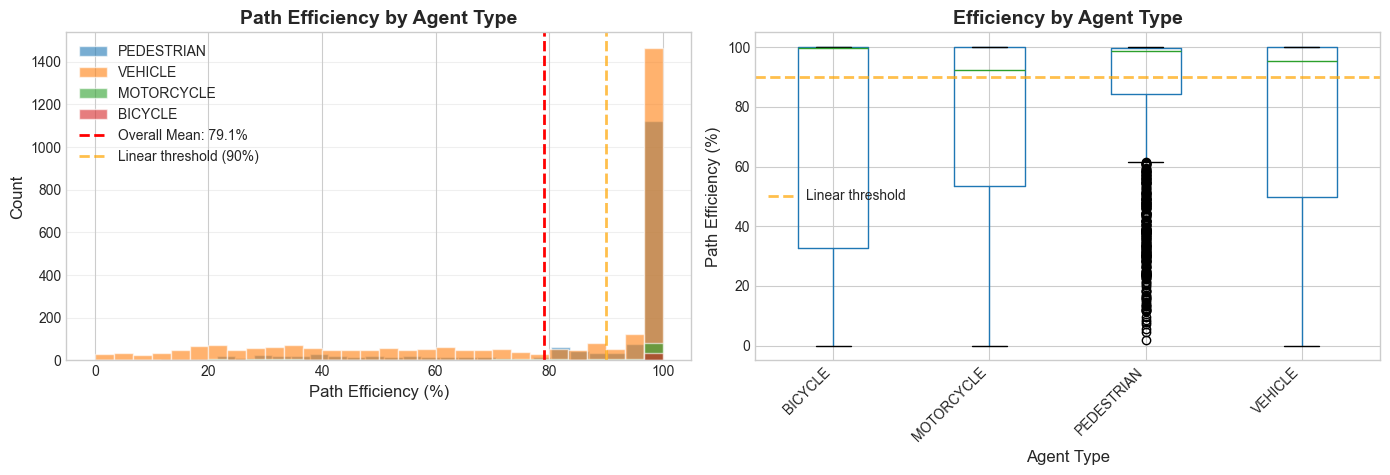


Path Efficiency Statistics by Agent Type:

PEDESTRIAN:
  Mean efficiency: 86.6%
  Median efficiency: 98.9%
  Linear trajectories (>90%): 71.3%
  Count: 1731

VEHICLE:
  Mean efficiency: 75.0%
  Median efficiency: 95.4%
  Linear trajectories (>90%): 54.2%
  Count: 3035

MOTORCYCLE:
  Mean efficiency: 76.3%
  Median efficiency: 92.2%
  Linear trajectories (>90%): 52.2%
  Count: 184

BICYCLE:
  Mean efficiency: 74.8%
  Median efficiency: 99.7%
  Linear trajectories (>90%): 66.0%
  Count: 50


In [16]:
# Visualize path efficiency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by agent type
ax = axes[0]
for agent_type in path_efficiency_df['agent_type'].unique():
    subset = path_efficiency_df[path_efficiency_df['agent_type'] == agent_type]['path_efficiency']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Path Efficiency (%)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Path Efficiency by Agent Type', fontsize=14, fontweight='bold')
ax.axvline(path_efficiency_df['path_efficiency'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Overall Mean: {path_efficiency_df["path_efficiency"].mean():.1f}%')
ax.axvline(90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Linear threshold (90%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Boxplot by agent type
ax = axes[1]
path_efficiency_df.boxplot(column='path_efficiency', by='agent_type', ax=ax)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Path Efficiency (%)', fontsize=12)
ax.set_title('Efficiency by Agent Type', fontsize=14, fontweight='bold')
ax.axhline(90, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Linear threshold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.get_figure().suptitle('')  # Remove default title
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'path_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\nPath Efficiency Statistics by Agent Type:")
for agent_type in path_efficiency_df['agent_type'].unique():
    subset = path_efficiency_df[path_efficiency_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Mean efficiency: {subset['path_efficiency'].mean():.1f}%")
    print(f"  Median efficiency: {subset['path_efficiency'].median():.1f}%")
    print(f"  Linear trajectories (>90%): {(subset['path_efficiency'] >= 90).mean()*100:.1f}%")
    print(f"  Count: {len(subset)}")

## Metric 7: Heading Change Distribution

Compute cumulative angular deviation from initial heading.

### What is computed:

This metric quantifies **total heading change** throughout each trajectory to identify turning behavior and maneuver complexity.

### How it works:

1. **Heading Derivation**:
   - Computes movement direction from position deltas: `deltas = diff(positions)`
   - Calculates heading angles: `headings = arctan2(delta_y, delta_x)`
2. **Heading Changes**:
   - Computes differences between consecutive headings: `diff(headings)`
3. **Angle Wrapping**:
   - Normalizes angles to [-pi, pi] using: `arctan2(sin(theta), cos(theta))`
   - Ensures shortest angular distance is measured
4. **Cumulative Change**:
   - Sums absolute heading changes over the entire trajectory
   - Converts from radians to degrees for interpretability

### Output:
- Total cumulative heading change in degrees
- Mean and median values across all trajectories
- Histogram showing distribution (straight paths ~0 degrees, complex turns >90 degrees)

In [17]:
print('Preparing heading change metrics from cached characteristic metrics...')

heading_change_df = metrics_df[['agent_type', 'heading_change']].copy()

print('')
print(f"✓ Heading change prepared for {len(heading_change_df)} trajectories")
print('')
print('Overall statistics:')
print(f"  Mean heading change: {heading_change_df['heading_change'].mean():.1f}°")
print(f"  Median heading change: {heading_change_df['heading_change'].median():.1f}°")


Computing heading changes...


Computing heading changes: 100%|██████████| 5000/5000 [01:11<00:00, 69.75it/s]


✓ Heading change computed for 5000 trajectories

Overall statistics:
  Mean heading change: 237.3°
  Median heading change: 99.0°


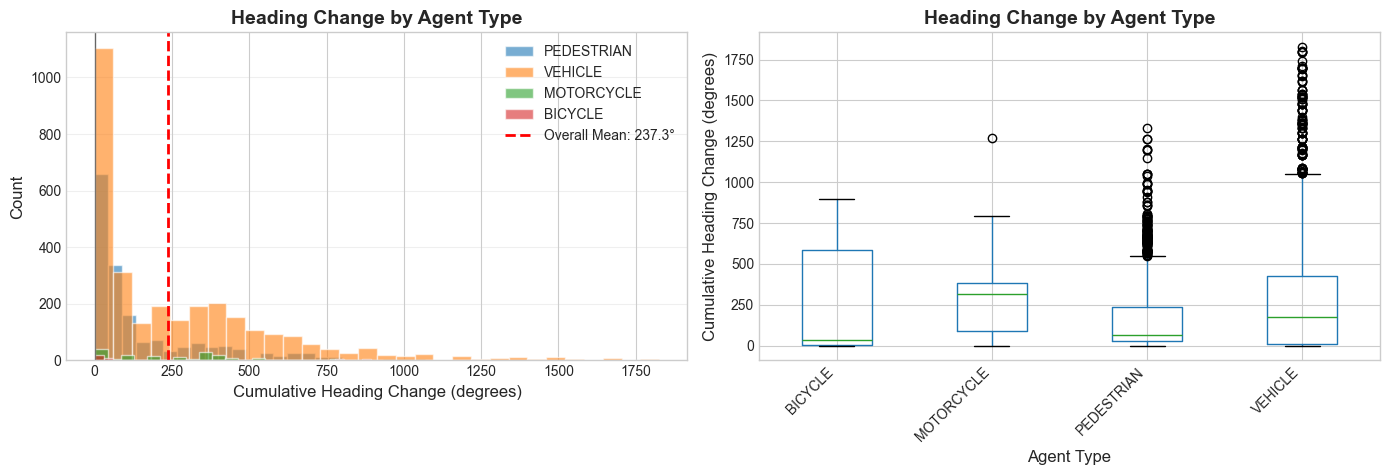


Heading Change Statistics by Agent Type:

PEDESTRIAN:
  Mean heading change: 167.6°
  Median heading change: 66.9°
  Max heading change: 1334.1°
  Count: 1731

VEHICLE:
  Mean heading change: 274.2°
  Median heading change: 172.8°
  Max heading change: 1825.8°
  Count: 3035

MOTORCYCLE:
  Mean heading change: 281.7°
  Median heading change: 315.0°
  Max heading change: 1268.5°
  Count: 184

BICYCLE:
  Mean heading change: 249.0°
  Median heading change: 33.2°
  Max heading change: 895.1°
  Count: 50


In [18]:
# Visualize heading change distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by agent type
ax = axes[0]
for agent_type in heading_change_df['agent_type'].unique():
    subset = heading_change_df[heading_change_df['agent_type'] == agent_type]['heading_change']
    ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Cumulative Heading Change (degrees)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Heading Change by Agent Type', fontsize=14, fontweight='bold')
ax.axvline(heading_change_df['heading_change'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Overall Mean: {heading_change_df["heading_change"].mean():.1f}°')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Boxplot by agent type
ax = axes[1]
heading_change_df.boxplot(column='heading_change', by='agent_type', ax=ax)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Cumulative Heading Change (degrees)', fontsize=12)
ax.set_title('Heading Change by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'heading_change_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\nHeading Change Statistics by Agent Type:")
for agent_type in heading_change_df['agent_type'].unique():
    subset = heading_change_df[heading_change_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Mean heading change: {subset['heading_change'].mean():.1f}°")
    print(f"  Median heading change: {subset['heading_change'].median():.1f}°")
    print(f"  Max heading change: {subset['heading_change'].max():.1f}°")
    print(f"  Count: {len(subset)}")

## Metric 8: Safety Metrics (Collision & Off-Road Detection)

Detect potential collisions and off-road events.

### What is computed:

This metric detects potential **safety violations** including near-collisions and off-road events.

### How it works:

#### Collision Detection:
1. **Agent Position**: Extracts current position from `agent_history_np[-1, :2]`
2. **Neighbor Positions**: Iterates through all neighbor trajectories in `neighbor_histories`
3. **Distance Check**:
   - Computes center-to-center distance to each neighbor
   - Flags collision if distance < 0.75m (COLLISION_THRESHOLD)
4. **Minimum Distance**: Tracks closest neighbor distance

#### Off-Road Detection:
1. **Map Availability**: Checks if vector map data exists (`vec_map`)
2. **Lane Proximity**:
   - Extracts lane centerlines from vector map
   - Computes distances from agent to all lane centers
   - Flags off-road if minimum distance > 3.0m
3. **Conservative Heuristic**: Uses simple distance threshold (may have false positives)

### Output:
- Collision event count and percentage
- Off-road event count and percentage
- Distribution of minimum neighbor distances
- Dual visualization: event counts (log scale) + distance histogram

In [21]:
print('Preparing safety metrics from cached characteristic metrics...')

safety_df = metrics_df[
    ['agent_type', 'has_collision', 'min_neighbor_distance', 'off_road']
].copy()

# Track missing data (NaN indicates not available)
missing_neighbor_count = safety_df['min_neighbor_distance'].isna().sum()
missing_vec_map_count = safety_df['off_road'].isna().sum()

# Convert float flags to cleaner numeric rates
safety_df['has_collision'] = safety_df['has_collision'].fillna(0.0)

collision_count = safety_df['has_collision'].sum()
off_road_count = safety_df['off_road'].fillna(0.0).sum()

print('')
print(f"✓ Safety metrics prepared from {len(safety_df)} samples")
print(f"  Missing neighbor data: {missing_neighbor_count} samples")
print(f"  Missing vector map data: {missing_vec_map_count} samples")
print('')
print('Safety Statistics:')
print(f"  Collision events: {collision_count:.0f} ({collision_count/len(safety_df)*100:.2f}%)")
print(f"  Off-road events: {off_road_count:.0f} ({off_road_count/len(safety_df)*100:.2f}%)")
print('')
print('Neighbor Distance Stats (excluding NaN):')
valid_distances = safety_df['min_neighbor_distance'].dropna()
if len(valid_distances) > 0:
    print(f"  Mean: {valid_distances.mean():.2f}m")
    print(f"  Median: {valid_distances.median():.2f}m")
    print(f"  Min: {valid_distances.min():.2f}m")
    print(f"  Max: {valid_distances.max():.2f}m")


Computing safety metrics...


Computing safety metrics: 100%|██████████| 5000/5000 [01:16<00:00, 65.41it/s]


✓ Safety metrics computed from 5000 samples
  Missing neighbor data: 0 samples
  Missing vector map data: 5000 samples

Safety Statistics:
  Collision events: 271 (5.42%)
  Off-road events: 0 (0.00%)

Neighbor Distance Stats (excluding None):
  Mean: 5.23m
  Median: 3.84m
  Min: 0.42m
  Max: 37.48m


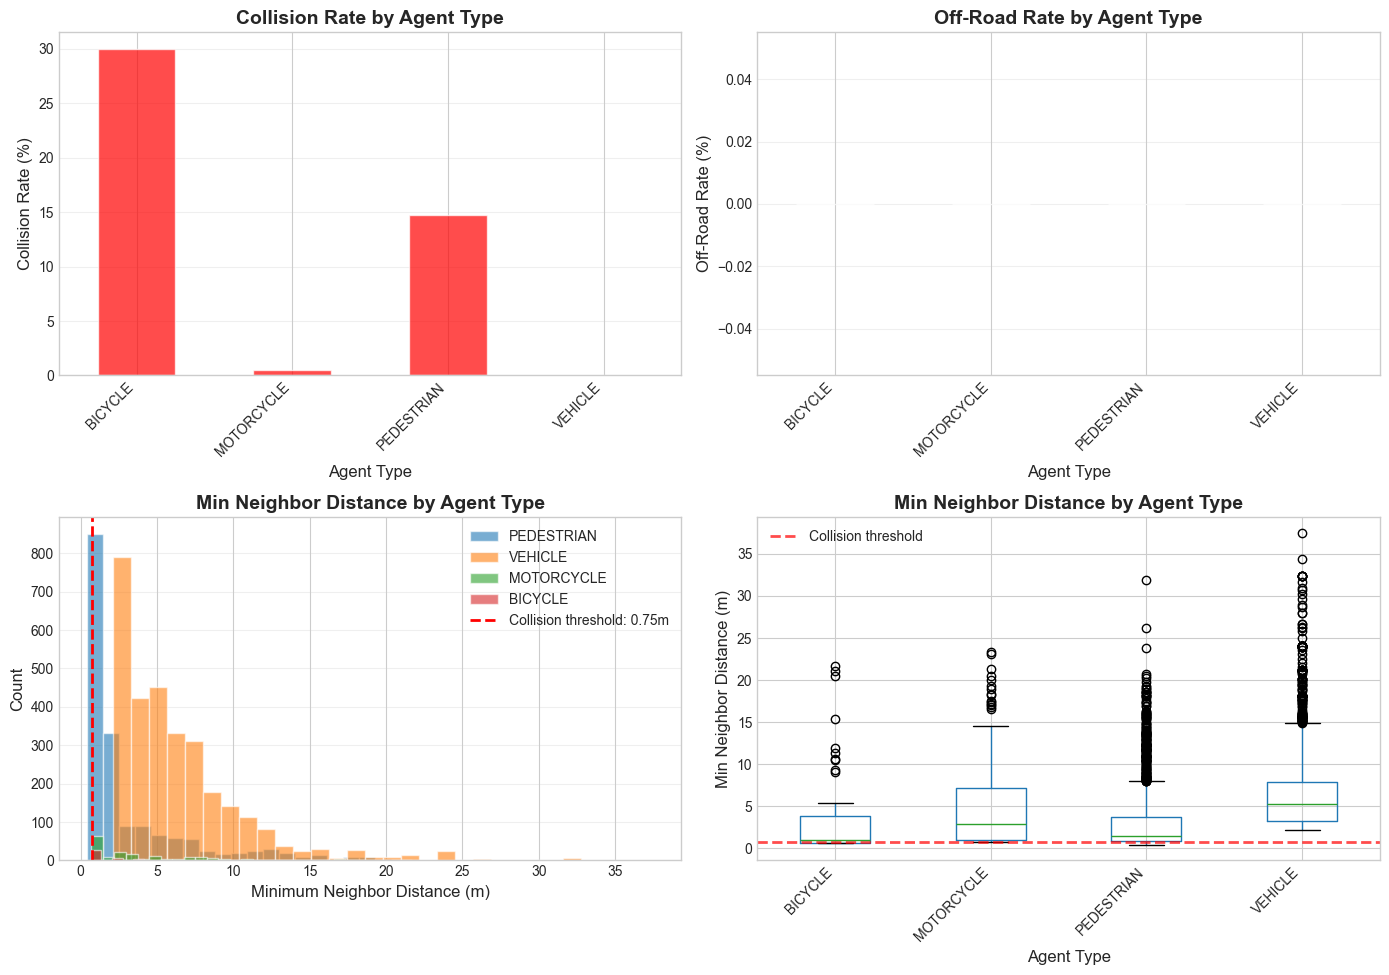


Safety Metrics by Agent Type:

PEDESTRIAN:
  Collision events: 255 (14.7%)
  Off-road events: 0 (0.0%)
  Mean min neighbor distance: 3.21 m
  Count: 1731

VEHICLE:
  Collision events: 0 (0.0%)
  Off-road events: 0 (0.0%)
  Mean min neighbor distance: 6.43 m
  Count: 3035

MOTORCYCLE:
  Collision events: 1 (0.5%)
  Off-road events: 0 (0.0%)
  Mean min neighbor distance: 4.85 m
  Count: 184

BICYCLE:
  Collision events: 15 (30.0%)
  Off-road events: 0 (0.0%)
  Mean min neighbor distance: 4.04 m
  Count: 50


In [22]:
COLLISION_THRESHOLD = float(config["analysis"]["collision_threshold_m"])
if "metric_cfg" in globals():
    COLLISION_THRESHOLD = float(metric_cfg.collision_threshold_m)

# Visualize safety metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grouped bar chart for collision events by agent type
ax = axes[0, 0]
collision_by_type = safety_df.groupby('agent_type')['has_collision'].agg(['sum', 'count'])
collision_by_type['rate'] = (collision_by_type['sum'] / collision_by_type['count'] * 100)
collision_by_type['rate'].plot(kind='bar', ax=ax, color='red', alpha=0.7)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Collision Rate (%)', fontsize=12)
ax.set_title('Collision Rate by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Grouped bar chart for off-road events by agent type
ax = axes[0, 1]
offroad_by_type = safety_df.groupby('agent_type')['off_road'].agg(['sum', 'count'])
offroad_by_type['rate'] = (offroad_by_type['sum'] / offroad_by_type['count'] * 100)
offroad_by_type['rate'].plot(kind='bar', ax=ax, color='orange', alpha=0.7)
ax.set_xlabel('Agent Type', fontsize=12)
ax.set_ylabel('Off-Road Rate (%)', fontsize=12)
ax.set_title('Off-Road Rate by Agent Type', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Minimum neighbor distance by agent type
ax = axes[1, 0]
for agent_type in safety_df['agent_type'].unique():
    subset = safety_df[safety_df['agent_type'] == agent_type]['min_neighbor_distance'].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=30, alpha=0.6, label=agent_type)
ax.set_xlabel('Minimum Neighbor Distance (m)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Min Neighbor Distance by Agent Type', fontsize=14, fontweight='bold')
ax.axvline(COLLISION_THRESHOLD, color='red', linestyle='--', 
           linewidth=2, label=f'Collision threshold: {COLLISION_THRESHOLD}m')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Boxplot of minimum neighbor distance by agent type
ax = axes[1, 1]
safety_df_with_distances = safety_df[safety_df['min_neighbor_distance'].notna()]
if len(safety_df_with_distances) > 0:
    safety_df_with_distances.boxplot(column='min_neighbor_distance', by='agent_type', ax=ax)
    ax.set_xlabel('Agent Type', fontsize=12)
    ax.set_ylabel('Min Neighbor Distance (m)', fontsize=12)
    ax.set_title('Min Neighbor Distance by Agent Type', fontsize=14, fontweight='bold')
    ax.axhline(COLLISION_THRESHOLD, color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label='Collision threshold')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')
    ax.get_figure().suptitle('')  # Remove default title
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'safety_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\nSafety Metrics by Agent Type:")
for agent_type in safety_df['agent_type'].unique():
    subset = safety_df[safety_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Collision events: {subset['has_collision'].sum()} ({subset['has_collision'].mean()*100:.1f}%)")
    print(f"  Off-road events: {subset['off_road'].sum()} ({subset['off_road'].mean()*100:.1f}%)")
    if subset['min_neighbor_distance'].notna().any():
        print(f"  Mean min neighbor distance: {subset['min_neighbor_distance'].mean():.2f} m")
    print(f"  Count: {len(subset)}")


## Export Results

Save aggregated statistics and metrics to JSON.

In [23]:
# Helper function to compute stats by agent type
def compute_agent_type_stats(df, metric_cols):
    """Compute statistics grouped by agent type."""
    stats = {}
    for agent_type in df['agent_type'].unique():
        subset = df[df['agent_type'] == agent_type]
        agent_stats = {'count': len(subset)}
        for col in metric_cols:
            if col in subset.columns:
                agent_stats[f'{col}_mean'] = float(subset[col].mean())
                agent_stats[f'{col}_median'] = float(subset[col].median())
                if subset[col].dtype in ['float64', 'int64']:
                    agent_stats[f'{col}_std'] = float(subset[col].std())
                    agent_stats[f'{col}_min'] = float(subset[col].min())
                    agent_stats[f'{col}_max'] = float(subset[col].max())
        stats[agent_type] = agent_stats
    return stats

# Aggregate all metrics with agent type breakdowns
trajectory_metrics = {
    'sample_size': sample_size,
    'agent_type_distribution': agent_type_counts,
    
    'velocity_statistics': {
        'overall': {
            'mean_speed': float(velocity_df['mean_speed'].mean()),
            'median_speed': float(velocity_df['mean_speed'].median()),
            'max_speed': float(velocity_df['max_speed'].max()),
            'std_speed': float(velocity_df['std_speed'].mean())
        },
        'by_agent_type': compute_agent_type_stats(velocity_df, ['mean_speed', 'max_speed', 'std_speed'])
    },
    
    'acceleration_statistics': {
        'overall': {
            'mean_acceleration': float(accel_df['mean_acceleration'].abs().mean()),
            'max_acceleration': float(accel_df['max_acceleration'].max()),
            'mean_jerk': float(accel_df['mean_jerk'].mean()),
            'max_jerk': float(accel_df['max_jerk'].max())
        },
        'by_agent_type': compute_agent_type_stats(accel_df, ['mean_acceleration', 'max_acceleration', 'mean_jerk', 'max_jerk'])
    },
    
    'duration_statistics': {
        'overall': {
            'mean_total_duration': float(duration_df['duration'].mean()),
            'mean_history_duration': float(duration_df['history_duration'].mean()),
            'mean_future_duration': float(duration_df['future_duration'].mean())
        },
        'by_agent_type': compute_agent_type_stats(duration_df, ['duration', 'history_duration', 'future_duration'])
    },
    
    'ego_distance_statistics': {
        'overall': {
            'mean_distance': float(ego_distance_df['ego_distance'].mean()),
            'median_distance': float(ego_distance_df['ego_distance'].median()),
            'min_distance': float(ego_distance_df['ego_distance'].min()),
            'max_distance': float(ego_distance_df['ego_distance'].max())
        },
        'by_agent_type': compute_agent_type_stats(ego_distance_df, ['ego_distance'])
    },
    
    'path_efficiency_statistics': {
        'overall': {
            'mean_efficiency': float(path_efficiency_df['path_efficiency'].mean()),
            'median_efficiency': float(path_efficiency_df['path_efficiency'].median()),
            'linear_trajectories_pct': float((path_efficiency_df['path_efficiency'] >= 90).mean() * 100)
        },
        'by_agent_type': compute_agent_type_stats(path_efficiency_df, ['path_efficiency', 'displacement', 'path_length'])
    },
    
    'heading_change_statistics': {
        'overall': {
            'mean_heading_change': float(heading_change_df['heading_change'].mean()),
            'median_heading_change': float(heading_change_df['heading_change'].median())
        },
        'by_agent_type': compute_agent_type_stats(heading_change_df, ['heading_change'])
    },
    
    'safety_statistics': {
        'overall': {
            'collision_count': int(safety_df['has_collision'].sum()),
            'collision_rate': float(safety_df['has_collision'].mean()),
            'off_road_count': int(safety_df['off_road'].sum()),
            'off_road_rate': float(safety_df['off_road'].mean()),
            'mean_min_neighbor_distance': float(safety_df['min_neighbor_distance'].mean()) if safety_df['min_neighbor_distance'].notna().any() else None,
            'collision_threshold_m': COLLISION_THRESHOLD
        },
        'by_agent_type': {}
    }
}

# Add agent type breakdown for safety metrics
for agent_type in safety_df['agent_type'].unique():
    subset = safety_df[safety_df['agent_type'] == agent_type]
    trajectory_metrics['safety_statistics']['by_agent_type'][agent_type] = {
        'count': len(subset),
        'collision_count': int(subset['has_collision'].sum()),
        'collision_rate': float(subset['has_collision'].mean()),
        'off_road_count': int(subset['off_road'].sum()),
        'off_road_rate': float(subset['off_road'].mean()),
        'mean_min_neighbor_distance': float(subset['min_neighbor_distance'].mean()) if subset['min_neighbor_distance'].notna().any() else None
    }

# Save to JSON
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

with open(processed_path / 'trajectory_metrics.json', 'w') as f:
    json.dump(trajectory_metrics, f, indent=2)

print(f"✓ Trajectory metrics saved to: {processed_path / 'trajectory_metrics.json'}")
print(f"✓ All plots saved to: {PLOTS_DIR}")

✓ Trajectory metrics saved to: ../data/processed/trajectory_metrics.json
✓ All plots saved to: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/evaluation/plots/characterization


## Summary

Display key findings from the trajectory analysis.

In [24]:
print("\n" + "="*70)
print("📊 TRAJECTORY METRICS ANALYSIS SUMMARY")
print("="*70)

print(f"\n1. AGENT TYPE DISTRIBUTION:")
for agent_type, count in agent_type_counts.most_common():
    print(f"   • {agent_type}: {count} ({count/len(agent_types)*100:.1f}%)")

print(f"\n2. VELOCITY CHARACTERISTICS:")
print(f"   Overall:")
print(f"   • Mean speed: {velocity_df['mean_speed'].mean():.2f} m/s")
print(f"   • Max speed observed: {velocity_df['max_speed'].max():.2f} m/s")
print(f"   By Agent Type:")
for agent_type in velocity_df['agent_type'].unique():
    subset = velocity_df[velocity_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['mean_speed'].mean():.2f} m/s (mean)")

print(f"\n3. ACCELERATION & JERK:")
print(f"   Overall:")
print(f"   • Mean acceleration: {accel_df['mean_acceleration'].abs().mean():.2f} m/s²")
print(f"   • Mean jerk: {accel_df['mean_jerk'].mean():.2f} m/s³")
print(f"   By Agent Type:")
for agent_type in accel_df['agent_type'].unique():
    subset = accel_df[accel_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['mean_acceleration'].abs().mean():.2f} m/s² (accel)")

print(f"\n4. OBSERVATION DURATION:")
print(f"   Overall:")
print(f"   • Mean total duration: {duration_df['duration'].mean():.2f} s")
print(f"   By Agent Type:")
for agent_type in duration_df['agent_type'].unique():
    subset = duration_df[duration_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['duration'].mean():.2f} s")

print(f"\n5. EGO-AGENT DISTANCE:")
print(f"   Overall:")
print(f"   • Mean distance: {ego_distance_df['ego_distance'].mean():.2f} m")
print(f"   • Min distance: {ego_distance_df['ego_distance'].min():.2f} m")
print(f"   By Agent Type:")
for agent_type in ego_distance_df['agent_type'].unique():
    subset = ego_distance_df[ego_distance_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['ego_distance'].mean():.2f} m (mean)")

print(f"\n6. PATH EFFICIENCY:")
print(f"   Overall:")
print(f"   • Mean efficiency: {path_efficiency_df['path_efficiency'].mean():.1f}%")
print(f"   • Linear trajectories (>90%): {(path_efficiency_df['path_efficiency'] >= 90).mean()*100:.1f}%")
print(f"   By Agent Type:")
for agent_type in path_efficiency_df['agent_type'].unique():
    subset = path_efficiency_df[path_efficiency_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['path_efficiency'].mean():.1f}% (mean)")

print(f"\n7. HEADING CHANGE:")
print(f"   Overall:")
print(f"   • Mean cumulative change: {heading_change_df['heading_change'].mean():.1f}°")
print(f"   By Agent Type:")
for agent_type in heading_change_df['agent_type'].unique():
    subset = heading_change_df[heading_change_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['heading_change'].mean():.1f}°")

print(f"\n8. SAFETY METRICS:")
print(f"   Overall:")
print(f"   • Collision events: {safety_df['has_collision'].sum()} ({safety_df['has_collision'].mean()*100:.1f}%)")
print(f"   • Off-road events: {safety_df['off_road'].sum()} ({safety_df['off_road'].mean()*100:.1f}%)")
print(f"   By Agent Type:")
for agent_type in safety_df['agent_type'].unique():
    subset = safety_df[safety_df['agent_type'] == agent_type]
    print(f"   • {agent_type}: {subset['has_collision'].sum()} collisions ({subset['has_collision'].mean()*100:.1f}%), {subset['off_road'].sum()} off-road ({subset['off_road'].mean()*100:.1f}%)")

print("\n" + "="*70)
print("✓ Analysis complete with agent type differentiation.")
print("="*70)


📊 TRAJECTORY METRICS ANALYSIS SUMMARY

1. AGENT TYPE DISTRIBUTION:
   • VEHICLE: 3035 (60.7%)
   • PEDESTRIAN: 1731 (34.6%)
   • MOTORCYCLE: 184 (3.7%)
   • BICYCLE: 50 (1.0%)

2. VELOCITY CHARACTERISTICS:
   Overall:
   • Mean speed: 1.91 m/s
   • Max speed observed: 50.61 m/s
   By Agent Type:
   • PEDESTRIAN: 1.39 m/s (mean)
   • VEHICLE: 2.22 m/s (mean)
   • MOTORCYCLE: 1.62 m/s (mean)
   • BICYCLE: 2.23 m/s (mean)

3. ACCELERATION & JERK:
   Overall:
   • Mean acceleration: 0.13 m/s²
   • Mean jerk: 17.54 m/s³
   By Agent Type:
   • PEDESTRIAN: 0.08 m/s² (accel)
   • VEHICLE: 0.16 m/s² (accel)
   • MOTORCYCLE: 0.16 m/s² (accel)
   • BICYCLE: 0.09 m/s² (accel)

4. OBSERVATION DURATION:
   Overall:
   • Mean total duration: 8.10 s
   By Agent Type:
   • PEDESTRIAN: 8.10 s
   • VEHICLE: 8.10 s
   • MOTORCYCLE: 8.10 s
   • BICYCLE: 8.10 s

5. EGO-AGENT DISTANCE:
   Overall:
   • Mean distance: 28.47 m
   • Min distance: 3.04 m
   By Agent Type:
   • PEDESTRIAN: 23.77 m (mean)
   • VE